<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Heat%20Transfer/E_20_222_Heat_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.Cooling Load Calculation for Milk Storage

### 1.1 System Parameters

| Parameter | Symbol | Value |
| :--- | :--- | :--- |
| Number of containers | $n$ | 40 |
| Total mass of milk | $m_m$ | $200 \text{ kg}$ |
| Total mass of containers | $m_c$ | $80 \text{ kg}$ |
| Specific heat of milk | $C_{p,m}$ | $4000 \text{ J/kg K}$ |
| Specific heat of Aluminum | $C_{p,c}$ | $921.1 \text{ J/kg K}$ |
| Temperature Change | $\Delta T$ | $22.5 \text{ K}$ |
---
### 1.2.1 Case A: Average Initial Temperature ($T_i = 37.5^\circ\text{C}$)
*Calculated for the $35^\circ\text{C} - 40^\circ\text{C}$ range.*

**Total Heat Removal ($Q$):**
$$Q = n \times [(m_m \cdot c_m + m_c \cdot c_c) \times (T_i - T_f)]$$
$$Q = 40 \times [(5 \cdot 4000 + 2 \cdot 921.1) \times (37.5 - 15)]$$
$$Q = 19,657,980\text{ J} \approx 19.66\text{ MJ}$$

**Required Cooling Load ($\dot{Q}$):**
$$\dot{Q} = \frac{Q}{t} = \frac{19,657,980}{7200}$$
**$$\dot{Q}_{avg} \approx 2.73\text{ kW}$$**

---
### 1.2.2. Case B: Maximum Initial Temperature ($T_i = 40^\circ\text{C}$)
*Calculated for the worst-case scenario.*

**Total Heat Removal ($Q$):**
$$Q = 40 \times [(5 \cdot 4000 + 2 \cdot 921.1) \times (40 - 15)]$$
$$Q = 21,842,200\text{ J} \approx 21.84\text{ MJ}$$

**Required Cooling Load ($\dot{Q}$):**
$$\dot{Q} = \frac{Q}{t} = \frac{21,842,200}{7200}$$
**$$\dot{Q}_{max} \approx 3.03\text{ kW}$$**

In [1]:
# -------------------------------------------------
# ME421 - Cooling Load Calculation for Milk Storage
# -------------------------------------------------

# -----------------------------
# 1. Given System Parameters
# -----------------------------

n_containers = 40              # Number of containers
mass_milk = 5                  # kg per container
mass_container = 2             # kg per container

cp_milk = 4000                 # J/kg.K
cp_container = 921.1           # J/kg.K

T_final = 15.0                 # °C
cooling_time_hours = 2         # hours
cooling_time_sec = cooling_time_hours * 3600  # convert to seconds


# ---------------------------------
# 2. Cooling Load Calculation Function
# ---------------------------------

def cooling_load(initial_temperature):
    """
    Returns cooling load in kW for a given initial temperature.
    """

    delta_T = initial_temperature - T_final

    # Heat removed from milk
    Q_milk = n_containers * mass_milk * cp_milk * delta_T

    # Heat removed from containers
    Q_container = n_containers * mass_container * cp_container * delta_T

    # Total heat removal (Joules)
    Q_total = Q_milk + Q_container

    # Cooling load (Power) = Energy / Time
    load_watts = Q_total / cooling_time_sec

    # Convert to kW
    load_kW = load_watts / 1000

    return load_kW


# ---------------------------------
# 3. Temperature Scenarios
# ---------------------------------

T_avg = (35 + 40) / 2      # 37.5 °C
T_max = 40.0               # Worst case


# ---------------------------------
# 4. Results
# ---------------------------------

load_avg = cooling_load(T_avg)
load_max = cooling_load(T_max)

print("\n--- Cooling Load Results ---")
print(f"Initial Temperature : {T_avg:.1f} °C (Average)")
print(f"Required Load       : {load_avg:.3f} kW\n")

print(f"Initial Temperature : {T_max:.1f} °C (Maximum)")
print(f"Required Load       : {load_max:.3f} kW")



--- Cooling Load Results ---
Initial Temperature : 37.5 °C (Average)
Required Load       : 2.730 kW

Initial Temperature : 40.0 °C (Maximum)
Required Load       : 3.034 kW


## 2.Experimental Methodology for Unit Evaluation

This procedure outlines the experimental approach to determine the actual cooling capacity ($\dot{Q}_{act}$) of the laboratory unit and assess its feasibility for the milk cooling task.

---

### 2.1 Measurement Parameters
To analyze the system, the following physical and thermodynamic properties must be measured:

* **Duct Geometry:** Measure the width ($w$) and height ($h$) of the air intake duct to calculate the cross-sectional area ($A = w \times h$).
* **Air Velocity ($v$):** Use an anemometer to measure the air velocity at the intake. Multiple readings should be averaged to account for non-uniform flow.
* **Psychrometric States:** Measure the **Dry Bulb Temperature ($T_{db}$)** and **Wet Bulb Temperature ($T_{wb}$)** at:
    * **State 1 (Inlet):** Ambient air entering the evaporator.
    * **State 2 (Outlet):** Conditioned air exiting the evaporator.



---

### 2.2 Thermodynamic Calculations
The performance of the unit is governed by the enthalpy change of the air stream.

**Mass Flow Rate of Air ($\dot{m}_a$):**
$$\dot{m}_a = \rho \cdot A \cdot v$$
*Where $\rho \approx 1.2 \text{ kg/m}^3$ (density of air at STP).*

**Actual Cooling Capacity ($\dot{Q}_{act}$):**
Using the measured temperatures and a psychrometric chart, determine the specific enthalpy ($h$) for both states.
$$\dot{Q}_{act} = \dot{m}_a \times (h_{in} - h_{out})$$



---

### 2.3 Data Collection Table

| Parameter | Symbol | Unit | Value |
| :--- | :--- | :--- | :--- |
| Duct Area | $A$ | $m^2$ | |
| Avg. Air Velocity | $v$ | $m/s$ | |
| Inlet Enthalpy | $h_{in}$ | $kJ/kg$ | |
| Outlet Enthalpy | $h_{out}$ | $kJ/kg$ | |
| **Actual Cooling Capacity** | **$\dot{Q}_{act}$** | **kW** | |

---

### 2.4 Performance Validation Criteria
The unit is deemed suitable if its actual capacity meets the maximum required load calculated for the factory conditions:
* **Target Load (Max):** $3.03 \text{ kW}$
* **Decision Rule:**
    * If $\dot{Q}_{act} \geq 3.034 \text{ kW}$: **Suitable.**
    * If $\dot{Q}_{act} < 2.730 \text{ kW}$: **Insufficient; developments required.**

##3. Analysis of Evaporator Fan Speed and Experimental Results

This section evaluates the performance data collected across a range of evaporator fan settings. The experiment was conducted with the cold room door open to ensure consistent inlet air conditions, allowing for a clear assessment of how varying the mass flow rate affects the system's total heat extraction.

---

### 3.1 Instrumentation and Nomenclature
The following parameters were recorded to analyze the thermodynamic state of the air and the system's mechanical performance:

* **$D_1$**: Internal diameter of the air ducts (m)
* **$T_{1}, T_{2}$**: Dry bulb and wet bulb temperatures of the return air ($^\circ$C)
* **$T_{3}, T_{4}$**: Dry bulb and wet bulb temperatures at the **Evaporator Inlet** ($^\circ$C)
* **$T_{5}, T_{6}$**: Dry bulb and wet bulb temperatures at the **Evaporator Exit** ($^\circ$C)
* **$V_{in}$ / $V_{out}$**: Measured air velocity at the intake and exhaust points (m/s)

---

### 3.2 Experimental Data Table
*Fixed Duct Diameter ($D_1$): 0.11 m*

| Fan Speed | $T_1$ | $T_2$ | $T_3$ | $T_4$ | $T_5$ | $T_6$ | $V_{in}$ | $V_{out}$ |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | 29.5 | 25.2 | 29.1 | 21.2 | 26.4 | 19.9 | 0.0 | 0.0 |
| **2** | 29.5 | 25.3 | 29.1 | 21.1 | 26.7 | 20.0 | 0.0 | 0.0 |
| **3** | 29.9 | 25.3 | 29.5 | 21.5 | 24.3 | 19.7 | 0.6 | 0.5 |
| **4** | 30.0 | 24.9 | 29.6 | 21.8 | 20.4 | 16.6 | 2.8 | 2.6 |
| **5** | 29.2 | 23.7 | 29.3 | 21.2 | 20.8 | 16.2 | 5.6 | 5.4 |
| **6** | 29.2 | 23.3 | 29.3 | 21.1 | 21.4 | 18.0 | 8.8 | 8.1 |
| **7** | 29.4 | 23.2 | 29.3 | 21.1 | 21.5 | 18.2 | 9.3 | 8.4 |
| **8** | 29.0 | 23.1 | 29.1 | 21.0 | 21.2 | 17.6 | 9.6 | 8.5 |
| **9** | 28.7 | 22.9 | 28.9 | 20.9 | 21.3 | 17.4 | 9.8 | 8.7 |
| **10** | 29.4 | 23.2 | 29.3 | 21.1 | 19.9 | 16.5 | 9.5 | 9.1 |

---

## 3.3 Performance Discussion and Technical Analysis
The experimental investigation was conducted to evaluate the cooling performance of the evaporator under varying fan speed settings. The analysis focuses on the thermodynamic behavior of the air stream as it passes through the cooling coil.

### 3.3.1 Energy Exchange Across the Evaporator
The cooling capacity of the unit is fundamentally governed by the enthalpy reduction of the air between the inlet and outlet states. Air enters the evaporator at State ($T_3, T_4$) and exits at State ($T_5, T_6$). The decrease in wet-bulb temperature ($T_4 \rightarrow T_6$) represents the total heat removed from the air, which includes both sensible and latent components.

Since the total heat transfer rate is determined by:
$$\dot{Q}_{act} = \dot{m}_a (h_{in} - h_{out})$$

the primary performance indicator is the enthalpy difference ($\Delta h$) between the inlet and outlet air states. The wet-bulb temperature variation serves as a direct indicator of this total enthalpy change.



### 3.3.2 Influence of Air Mass Flow Rate
The air mass flow rate is given by:
$$\dot{m}_a = \rho A \bar{V}$$

where $\rho$ is the air density, $A$ is the duct cross-sectional area, and $\bar{V}$ is the average intake velocity.

As fan speed increases, the intake air velocity increases, thereby increasing the mass flow rate. Since cooling capacity is proportional to both mass flow rate and enthalpy reduction, higher fan speeds generally enhance the heat removal rate, provided that the enthalpy drop remains significant.

Experimental observations indicate that Speed 9 achieved the highest intake velocity ($9.8$ m/s). However, Speed 10 resulted in the lowest outlet dry-bulb and wet-bulb temperatures ($T_5 = 19.9^\circ$C and $T_6 = 16.5^\circ$C). This suggests that at Speed 10, the evaporator operates at a more favorable balance between airflow rate and air–coil contact effectiveness.

Although a slightly lower velocity was recorded compared to Speed 9, the greater enthalpy reduction at Speed 10 compensates for this, leading to improved overall cooling performance.

### 3.3.3 Determination of Optimal Operating Condition
The optimal operating point is defined as the fan speed that maximizes the actual cooling capacity ($\dot{Q}_{act}$). Based on the combined influence of mass flow rate and enthalpy drop, Speed 10 demonstrates superior thermodynamic performance among the tested conditions.

This behavior indicates that beyond a certain airflow rate, excessive velocity may reduce effective heat exchange due to decreased air–coil residence time. Therefore, maximum airflow does not necessarily correspond to maximum cooling capacity.

---

## 3.4 Feasibility Assessment
The required design cooling load for the milk storage application was previously determined to be:
$$\dot{Q}_{required} = 3.03 \text{ kW}$$

To verify feasibility, the experimentally calculated cooling capacities at higher fan speeds were compared with this threshold value.

**Decision Criteria:**
* If $\dot{Q}_{act} \geq 3.03 \text{ kW}$: The unit is considered suitable for cooling 200 kg of milk from $40^\circ$C to $15^\circ$C within the specified 2-hour duration.
* If the experimentally determined cooling rate falls below this requirement, system improvements such as increased capacity, enhanced airflow control, or improved insulation would be necessary.

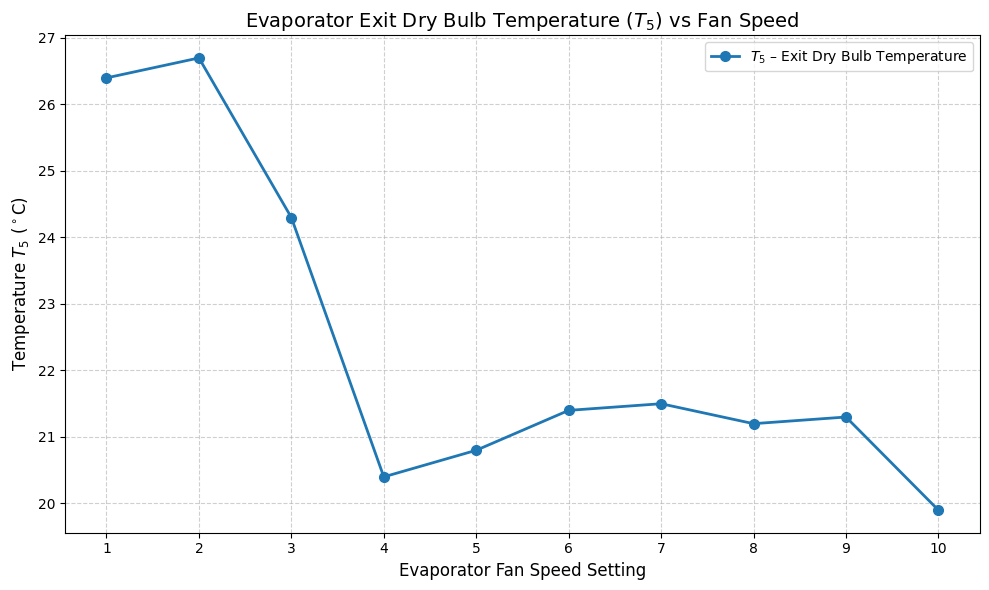

In [2]:
import matplotlib.pyplot as plt

# -----------------------------
# Experimental Measurements
# -----------------------------

speed_levels = list(range(1, 11))  # Fan speed settings (1–10)
temperature_T5 = [26.4, 26.7, 24.3, 20.4, 20.8,
                  21.4, 21.5, 21.2, 21.3, 19.9]

# -----------------------------
# Plot Configuration
# -----------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    speed_levels,
    temperature_T5,
    marker='o',
    linestyle='-',
    linewidth=2,
    markersize=7
)

# Titles and labels
ax.set_title(r'Evaporator Exit Dry Bulb Temperature ($T_5$) vs Fan Speed',
             fontsize=14)

ax.set_xlabel('Evaporator Fan Speed Setting', fontsize=12)
ax.set_ylabel(r'Temperature $T_5$ ($^\circ$C)', fontsize=12)

# Match x-axis ticks with discrete speed values
ax.set_xticks(speed_levels)

# Grid styling
ax.grid(True, linestyle='--', alpha=0.6)

# Legend
ax.legend([r'$T_5$ – Exit Dry Bulb Temperature'], loc='upper right')

# Layout adjustment
plt.tight_layout()

# Display graph
plt.show()


## 4. Thermodynamic Evaluation and Computational Logic

This section outlines the mathematical methodology employed to calculate the thermal performance of the refrigeration unit using experimental observations.

---

### 4.1 Air Mass Flow Rate Determination ($\dot{m}_a$)
The mass flow rate is a critical variable for determining the rate of energy exchange. It is calculated based on the continuity equation at the air intake:

$$\dot{m}_a = \rho \cdot A \cdot V_{in}$$

* **$\rho$**: Air density (taken as $1.2 \text{ kg/m}^3$ at standard conditions).
* **$A$**: Duct cross-sectional area ($m^2$).
* **$V_{in}$**: Average intake air velocity ($m/s$).

---

### 4.2 Analytical Calculation of Specific Enthalpy ($h$)
To quantify the total heat (comprising both sensible and latent components), specific enthalpy is derived from the experimental Dry Bulb ($T_{db}$) and Wet Bulb ($T_{wb}$) temperature readings.



#### **Step A: Determining Saturation Vapor Pressure ($P_{swb}$)**
The saturation vapor pressure at the wet bulb temperature is estimated using the Magnus-Tetens relationship:
$$P_{swb} = 0.61078 \cdot \exp\left(\frac{17.27 \cdot T_{wb}}{T_{wb} + 237.3}\right)$$

#### **Step B: Calculating Actual Vapor Pressure ($P_v$)**
The partial pressure of water vapor is found by adjusting for the psychrometric cooling effect:
$$P_v = P_{swb} - 0.000662 \cdot P_{atm} \cdot (T_{db} - T_{wb})$$
* **$P_{atm}$**: Standard atmospheric pressure ($101.325 \text{ kPa}$).

#### **Step C: Defining Humidity Ratio ($\omega$)**
The mass of water vapor per unit mass of dry air is calculated as:
$$\omega = 0.62194 \cdot \frac{P_v}{P_{atm}-P_v}$$

#### **Step D: Resultant Specific Enthalpy ($h$)**
The total heat content per kilogram of dry air ($\text{kJ/kg}$) is expressed by:
$$h = (c_{p,a} \cdot T_{db}) + \omega \cdot (h_{fg} + c_{p,v} \cdot T_{db})$$

* **$c_{p,a}$**: $1.006 \text{ kJ/kg}\cdot\text{K}$ (Specific heat capacity of dry air).
* **$h_{fg}$**: $2501 \text{ kJ/kg}$ (Latent heat of water vaporization).
* **$c_{p,v}$**: $1.86 \text{ kJ/kg}\cdot\text{K}$ (Specific heat capacity of water vapor).

---

### 4.3 Total Cooling Capacity Assessment ($\dot{Q}$)
The system's actual cooling capacity is determined by the total enthalpy drop between the air entering the system and the air exiting the evaporator:

$$\dot{Q} = \dot{m}_a \cdot (h_{in} - h_{out})$$

* **$h_{in}$**: Inlet enthalpy derived from $T_1$ and $T_2$ (Return air conditions).
* **$h_{out}$**: Outlet enthalpy derived from $T_5$ and $T_6$ (Supply air conditions).

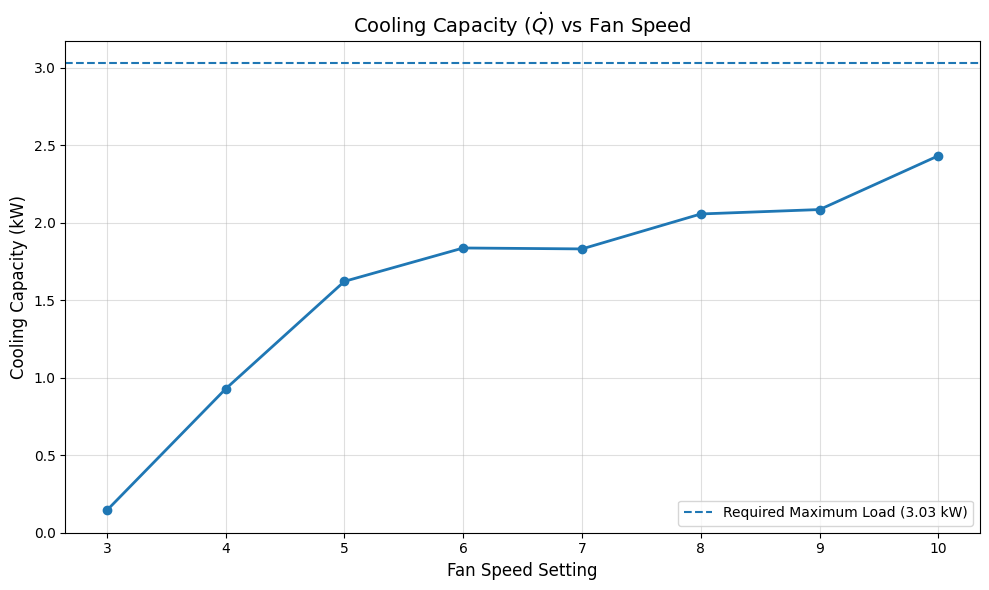


Cooling Capacity Results:
   speed  velocity      Q_kW
0      3       0.6  0.144262
1      4       2.8  0.928436
2      5       5.6  1.622419
3      6       8.8  1.837842
4      7       9.3  1.831778
5      8       9.6  2.057423
6      9       9.8  2.085847
7     10       9.5  2.433180


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Experimental Measurements
# --------------------------------------------------

experiment_data = pd.DataFrame({
    "speed": [3, 4, 5, 6, 7, 8, 9, 10],
    "T_db_in":  [29.9, 30.0, 29.2, 29.2, 29.4, 29.0, 28.7, 29.4],
    "T_wb_in":  [25.3, 24.9, 23.7, 23.3, 23.2, 23.1, 22.9, 23.2],
    "T_db_out": [24.3, 20.4, 20.8, 21.4, 21.5, 21.2, 21.3, 19.9],
    "T_wb_out": [19.7, 16.6, 16.2, 18.0, 18.2, 17.6, 17.4, 16.5],
    "velocity": [0.6, 2.8, 5.6, 8.8, 9.3, 9.6, 9.8, 9.5]
})

# --------------------------------------------------
# 2. System Constants
# --------------------------------------------------

P_atm = 101.325        # kPa
rho = 1.2              # kg/m^3 (air density)
duct_diameter = 0.11   # meters

duct_area = np.pi * duct_diameter**2 / 4


# --------------------------------------------------
# 3. Psychrometric Enthalpy Function
# --------------------------------------------------

def moist_air_enthalpy(Tdb, Twb):
    """
    Returns moist air enthalpy in kJ/kg
    using simplified psychrometric relations.
    """

    # Saturation vapor pressure at wet bulb temperature (kPa)
    P_ws = 0.61078 * np.exp((17.27 * Twb) / (Twb + 237.3))

    # Actual vapor pressure (kPa)
    P_v = P_ws - 0.000662 * P_atm * (Tdb - Twb)

    # Humidity ratio
    omega = 0.62194 * P_v / (P_atm - P_v)

    # Enthalpy (kJ/kg dry air)
    h = 1.006 * Tdb + omega * (2501 + 1.86 * Tdb)

    return h


# --------------------------------------------------
# 4. Thermodynamic Calculations
# --------------------------------------------------

# Enthalpy at inlet and outlet
experiment_data["h_in"] = moist_air_enthalpy(
    experiment_data["T_db_in"],
    experiment_data["T_wb_in"]
)

experiment_data["h_out"] = moist_air_enthalpy(
    experiment_data["T_db_out"],
    experiment_data["T_wb_out"]
)

# Air mass flow rate (kg/s)
experiment_data["m_dot"] = rho * duct_area * experiment_data["velocity"]

# Cooling capacity (kW)
experiment_data["Q_kW"] = (
    experiment_data["m_dot"] *
    (experiment_data["h_in"] - experiment_data["h_out"])
)

# --------------------------------------------------
# 5. Plot Cooling Capacity vs Fan Speed
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    experiment_data["speed"],
    experiment_data["Q_kW"],
    marker='o',
    linewidth=2
)

ax.axhline(
    y=3.03,
    linestyle='--',
    label="Required Maximum Load (3.03 kW)"
)

ax.set_title(r'Cooling Capacity ($\dot{Q}$) vs Fan Speed', fontsize=14)
ax.set_xlabel("Fan Speed Setting", fontsize=12)
ax.set_ylabel("Cooling Capacity (kW)", fontsize=12)

ax.grid(True, alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. Display Key Results
# --------------------------------------------------

print("\nCooling Capacity Results:")
print(experiment_data[["speed", "velocity", "Q_kW"]])


## 5. Experimental Summary and Procedural Transition

Following the analysis of the discharge temperatures ($T_5, T_6$) and the resulting heat extraction rates ($\dot{Q}$) across the fan speed spectrum, the following findings have been established:

---

### 5.1 Fan Speed Optimization Analysis
* **Maximum Efficiency Point:** Empirical data indicates that the system achieves its peak thermal performance when the **evaporator fan is operated at its highest setting**.
* **Optimal Configuration:** While the peak air velocity was recorded at speed 9, the most significant cooling effect occurred at **Speed 10**, yielding the minimum exit temperatures of $19.9^\circ$C (dry bulb) and $16.5^\circ$C (wet bulb).
* **Mass Flow Dominance:** The increase in mass flow rate ($\dot{m}_a$) at high speeds effectively compensates for the reduced residence time of air over the cooling coils, resulting in a superior net cooling capacity (kW).
* **Capacity Assessment:** Initial calculations indicate that the system's current heat removal rate remains below the required design thresholds of **2.73 kW** and **3.03 kW**.



---

### 5.2 Subsequent Phase: Closed-Environment Thermal Decay Test
With the optimal operating speed identified, the next stage of the evaluation focuses on the unit's performance within a sealed environment to simulate actual storage conditions.

* **Primary Objective:** To quantify the cooling rate ($\frac{dT}{dt}$) within the internal storage volume.
* **Methodology:** The cold room will be sealed, and the system will run continuously at the **maximum fan speed** determined in the previous phase.
* **Performance Metrics:** The internal temperature decline will be monitored over time. This data is critical to verify if the unit can drive the environment down to the target storage temperature of **15°C** within the necessary **two-hour limit**.